In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

#**Random forest (Regression) model for calculator**

In [2]:
df = pd.read_csv('/content/Carbon Emission (2).csv')
df.head()

,Body Type,Sex,How Often Shower,Heating Energy Source,Social Activity,How Long TV PC Daily Hour,Energy efficiency,Transport,Vehicle Type,Vehicle Monthly Distance Km,...,Diet,Waste Bag Size,Waste Bag Weekly Count,How Many New Clothes Monthly,How Long Internet Daily Hour,Individual_Component,Transport_Component,Industry_Component,Scope3_Component,Unified_Target
0,overweight,female,daily,coal,often,7,No,public,none,210,...,pescatarian,large,4,26,1,184,0.000000,64808.563700,261,65253.563700
1,obese,female,less frequently,natural gas,often,9,No,walk/bicycle,none,9,...,vegetarian,extra large,3,38,5,148,0.000000,64706.229154,290,65144.229154
2,overweight,male,more frequently,wood,never,14,Sometimes,private,petrol,2472,...,omnivore,small,1,47,6,188,581.214982,64683.608985,356,65808.823967
3,overweight,male,twice a day,wood,sometimes,20,Sometimes,walk/bicycle,none,74,...,omnivore,medium,3,5,7,210,0.000000,64808.563700,177,65195.563700
4,obese,female,daily,coal,often,3,Yes,private,diesel,8457,...,vegetarian,large,1,5,6,196,2008.948269,64808.563700,96,67109.511969


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Body Type                      10000 non-null  object 
 1   Sex                            10000 non-null  object 
 2   How Often Shower               10000 non-null  object 
 3   Heating Energy Source          10000 non-null  object 
 4   Social Activity                10000 non-null  object 
 5   How Long TV PC Daily Hour      10000 non-null  int64  
 6   Energy efficiency              10000 non-null  object 
 7   Transport                      10000 non-null  object 
 8   Vehicle Type                   10000 non-null  object 
 9   Vehicle Monthly Distance Km    10000 non-null  int64  
 10  Frequency of Traveling by Air  10000 non-null  object 
 11  Industry_Sector                10000 non-null  object 
 12  Diet                           10000 non-null  

In [4]:
df.describe()

,How Long TV PC Daily Hour,Vehicle Monthly Distance Km,Waste Bag Weekly Count,How Many New Clothes Monthly,How Long Internet Daily Hour,Individual_Component,Transport_Component,Industry_Component,Scope3_Component,Unified_Target
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,12.139200,2031.485900,4.024600,25.109000,11.889100,164.173400,302.133822,64729.861193,257.88010,65454.048515
std,7.106369,2769.715597,1.990375,14.698725,7.277218,33.142314,626.830878,47.228454,84.50257,636.217081
min,0.000000,0.000000,1.000000,0.000000,0.000000,80.000000,0.000000,64683.608985,39.00000,64829.608985
25%,6.000000,69.000000,2.000000,13.000000,6.000000,140.000000,0.000000,64683.608985,192.00000,65103.400701
50%,12.000000,823.000000,4.000000,25.000000,12.000000,164.000000,0.000000,64706.229154,259.00000,65196.919070
75%,18.000000,2516.750000,6.000000,38.000000,18.000000,188.000000,88.158956,64722.400701,322.00000,65367.400701
max,24.000000,9999.000000,7.000000,50.000000,24.000000,258.000000,2746.517449,64808.563700,478.00000,68070.393478


In [5]:
df.shape

(10000, 22)

In [6]:
df.isnull().sum()

,0
Body Type,0
Sex,0
How Often Shower,0
Heating Energy Source,0
Social Activity,0
How Long TV PC Daily Hour,0
Energy efficiency,0
Transport,0
Vehicle Type,0
Vehicle Monthly Distance Km,0


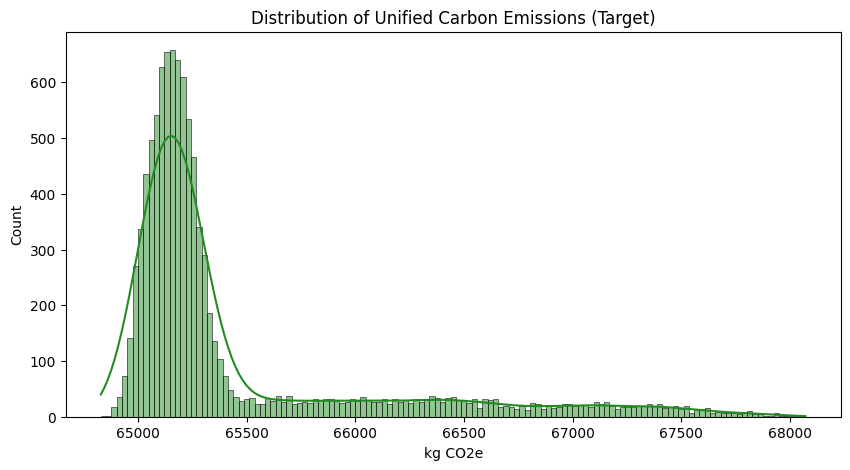

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Unified_Target'], kde=True, color='forestgreen')
plt.title('Distribution of Unified Carbon Emissions (Target)')
plt.xlabel('kg CO2e')
plt.show()

In [8]:
num_cols = df.select_dtypes(include='number')
num_cols.corr()

,How Long TV PC Daily Hour,Vehicle Monthly Distance Km,Waste Bag Weekly Count,How Many New Clothes Monthly,How Long Internet Daily Hour,Individual_Component,Transport_Component,Industry_Component,Scope3_Component,Unified_Target
How Long TV PC Daily Hour,1.000000,-0.003943,-0.011640,0.009414,0.006804,0.419033,0.004887,0.001752,0.002724,0.027135
Vehicle Monthly Distance Km,-0.003943,1.000000,-0.001730,0.004934,-0.003497,0.020421,0.828731,-0.008253,0.008112,0.818033
Waste Bag Weekly Count,-0.011640,-0.001730,1.000000,-0.003254,-0.005335,-0.012548,-0.003678,-0.003303,0.347821,0.041675
How Many New Clothes Monthly,0.009414,0.004934,-0.003254,1.000000,0.006426,0.017805,0.002312,0.012438,0.866506,0.119218
How Long Internet Daily Hour,0.006804,-0.003497,-0.005335,0.006426,1.000000,0.018648,-0.003842,-0.001048,0.089802,0.009036
Individual_Component,0.419033,0.020421,-0.012548,0.017805,0.018648,1.000000,0.020249,0.000130,0.008538,0.073186
Transport_Component,0.004887,0.828731,-0.003678,0.002312,-0.003842,0.020249,1.000000,-0.003782,0.006105,0.986832
Industry_Component,0.001752,-0.008253,-0.003303,0.012438,-0.001048,0.000130,-0.003782,1.000000,0.009168,0.071732
Scope3_Component,0.002724,0.008112,0.347821,0.866506,0.089802,0.008538,0.006105,0.009168,1.000000,0.139961
Unified_Target,0.027135,0.818033,0.041675,0.119218,0.009036,0.073186,0.986832,0.071732,0.139961,1.000000


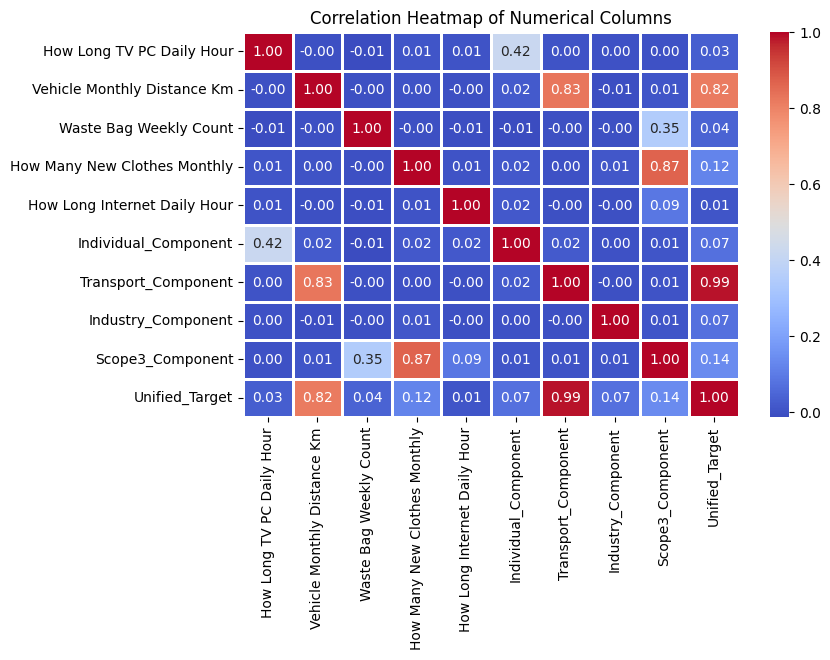

In [9]:
plt.figure(figsize=(8,5))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', linewidths=1, fmt=".2f")
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

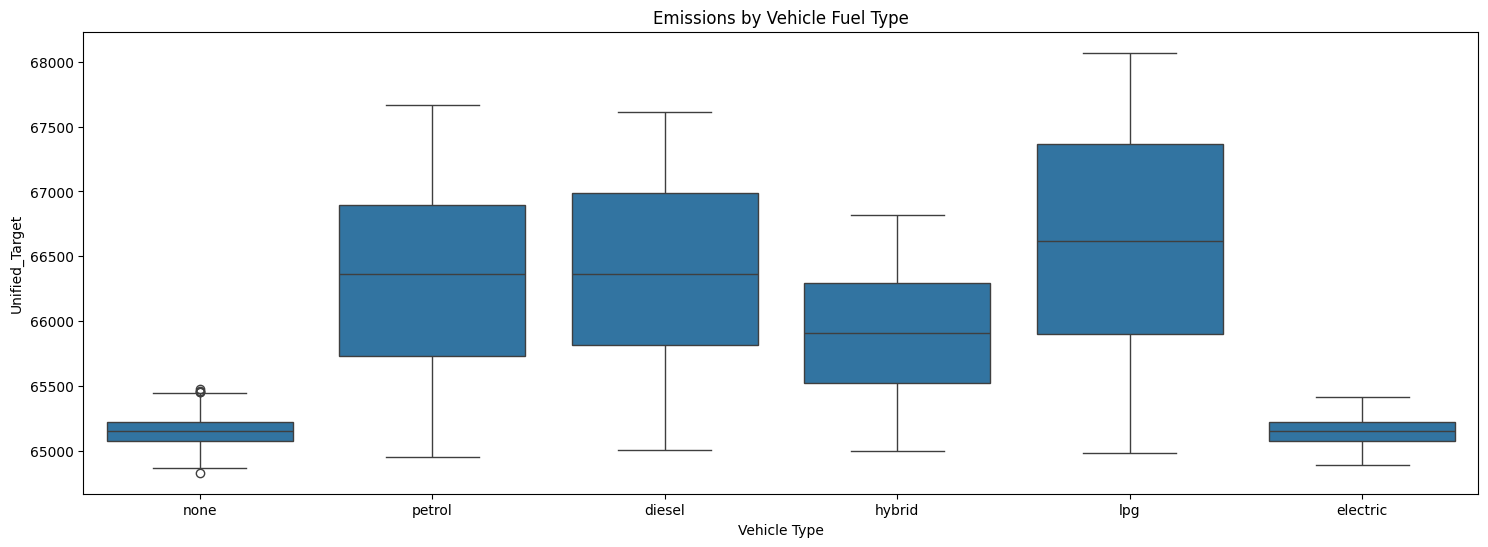

In [10]:
plt.subplots(figsize=(18, 6))
sns.boxplot(x='Vehicle Type', y='Unified_Target', data=df)
plt.title('Emissions by Vehicle Fuel Type')
plt.show()

In [11]:
from sklearn.ensemble import RandomForestRegressor
def train_model(df, features, target, model_name):
    # 1. Split features and target
    x = df[features].copy()
    y = df[target].copy()

    # 2. Identify numeric and categorical columns
    num_cols = x.select_dtypes(include=['int','float']).columns
    cat_cols = x.select_dtypes(include=['object']).columns
    x.loc[:, cat_cols] = x[cat_cols].astype(str)  # safe assignment

    # 3. Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        ]
    )

    X_processed = preprocessor.fit_transform(x)

    # Scale target for better model performance (optional)
    #target_scaler = StandardScaler()
    #y_scaled = target_scaler.fit_transform(y.values.reshape(-1, 1)).ravel()  # Flatten to 1D

    # 4. Train/test split
    x_train, x_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=0.2, random_state=42
    )

    # 5. Train RandomForest
    model = RandomForestRegressor(
        n_estimators=200,  # increase trees for better performance
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    model.fit(x_train, y_train)

    # 6. Evaluate
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"✅ {model_name} Results:")
    print(f"   - MSE: {mse:.4f}")
    print(f"   - R2 Score: {r2*100:.2f}%")

    # 7. Save model & preprocessor
    joblib.dump(model, f"{model_name}_tree_model.pkl")
    joblib.dump(preprocessor, f"{model_name}_preprocessor.pkl")
    print(f"💾 Files saved: {model_name}_tree_model.pkl & {model_name}_preprocessor.pkl\n")

In [12]:
df.columns

Index(['Body Type', 'Sex', 'How Often Shower', 'Heating Energy Source',
       'Social Activity', 'How Long TV PC Daily Hour', 'Energy efficiency',
       'Transport', 'Vehicle Type', 'Vehicle Monthly Distance Km',
       'Frequency of Traveling by Air', 'Industry_Sector', 'Diet',
       'Waste Bag Size', 'Waste Bag Weekly Count',
       'How Many New Clothes Monthly', 'How Long Internet Daily Hour',
       'Individual_Component', 'Transport_Component', 'Industry_Component',
       'Scope3_Component', 'Unified_Target'],
      dtype='object')

In [13]:
targets = [
    'Individual_Component',
    'Transport_Component',
    'Industry_Component',
    'Scope3_Component'
]

for col in targets:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=targets)

In [14]:
individual_features = ['Body Type', 'Sex', 'How Often Shower', 'Heating Energy Source', 'Social Activity', 'How Long TV PC Daily Hour', 'Energy efficiency']
transport_features = ['Transport', 'Vehicle Type', 'Vehicle Monthly Distance Km', 'Frequency of Traveling by Air']
industry_features = ['Industry_Sector']
scope3_features = ['Diet', 'Waste Bag Size', 'Waste Bag Weekly Count', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour']

In [15]:
df.columns

Index(['Body Type', 'Sex', 'How Often Shower', 'Heating Energy Source',
       'Social Activity', 'How Long TV PC Daily Hour', 'Energy efficiency',
       'Transport', 'Vehicle Type', 'Vehicle Monthly Distance Km',
       'Frequency of Traveling by Air', 'Industry_Sector', 'Diet',
       'Waste Bag Size', 'Waste Bag Weekly Count',
       'How Many New Clothes Monthly', 'How Long Internet Daily Hour',
       'Individual_Component', 'Transport_Component', 'Industry_Component',
       'Scope3_Component', 'Unified_Target'],
      dtype='object')

In [16]:

train_model(df, individual_features, 'Individual_Component', 'individual_model')

✅ individual_model Results:
   - MSE: 0.0661
   - R2 Score: 99.99%
💾 Files saved: individual_model_tree_model.pkl & individual_model_preprocessor.pkl



In [17]:
train_model(df, transport_features, 'Transport_Component', 'Vehicle_model')

✅ Vehicle_model Results:
   - MSE: 6.1817
   - R2 Score: 100.00%
💾 Files saved: Vehicle_model_tree_model.pkl & Vehicle_model_preprocessor.pkl



In [18]:
train_model(df, industry_features, 'Industry_Component', 'industry_model')

✅ industry_model Results:
   - MSE: 0.0000
   - R2 Score: 100.00%
💾 Files saved: industry_model_tree_model.pkl & industry_model_preprocessor.pkl



In [19]:
train_model(df,scope3_features,'Scope3_Component','scope3_model')

✅ scope3_model Results:
   - MSE: 7.1707
   - R2 Score: 99.90%
💾 Files saved: scope3_model_tree_model.pkl & scope3_model_preprocessor.pkl



In [20]:
import os
print(os.listdir())

['.config', 'class_names.pkl', 'individual_model_preprocessor.pkl', 'carbon_emission_model.keras', 'individual_model_tree_model.pkl', 'Carbon Emission (2).csv', 'industry_model_tree_model.pkl', 'scope3_model_preprocessor.pkl', 'scope3_model_tree_model.pkl', 'Vehicle_model_preprocessor.pkl', 'industry_model_preprocessor.pkl', 'Vehicle_model_tree_model.pkl', 'sample_data']


# **Convolutional Neural Network (Classification) Model for carbon emision prediction**

In [ ]:
!unzip -q "/content/IND_and_NEP.zip" -d "/content/Image_Folder" # exracting the zip file to a folder

In [ ]:
import os
base_path = '/content/'
print(os.listdir(base_path))

['.config', '.ipynb_checkpoints', 'Carbon Emission (2).csv', 'Vehicle_model_preprocessor.pkl', 'IND_and_NEP.zip', 'carbon_emission_model.keras', 'app.py', 'scope3_model_tree_model.pkl', 'class_names.pkl', 'industry_model_tree_model.pkl', 'industry_model_preprocessor.pkl', 'scope3_model_preprocessor.pkl', 'Image_Folder', 'individual_model_tree_model.pkl', 'Vehicle_model_tree_model.pkl', 'individual_model_preprocessor.pkl', 'sample_data']


In [ ]:
import tensorflow as tf
data = '/content/Image_Folder/IND_and_NEP'

array([[[224, 182, 163],
        [223, 181, 162],
        [223, 181, 162],
        ...,
        [224, 176, 152],
        [224, 176, 152],
        [224, 176, 152]],

       [[223, 181, 162],
        [223, 181, 162],
        [223, 181, 162],
        ...,
        [225, 177, 153],
        [225, 177, 153],
        [225, 177, 153]],

       [[223, 181, 162],
        [223, 181, 162],
        [223, 181, 162],
        ...,
        [225, 177, 153],
        [225, 177, 153],
        [225, 177, 153]],

       ...,

       [[195, 202, 221],
        [195, 203, 220],
        [190, 198, 215],
        ...,
        [114, 106, 117],
        [113, 105, 116],
        [116, 108, 119]],

       [[182, 189, 209],
        [181, 188, 207],
        [176, 183, 202],
        ...,
        [106, 101, 110],
        [106, 101, 110],
        [109, 104, 113]],

       [[175, 182, 202],
        [178, 185, 205],
        [178, 185, 205],
        ...,
        [103,  99, 105],
        [105, 101, 107],
        [103,  99, 105]]], dtype=uint8)
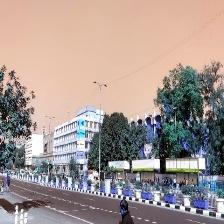

In [ ]:
import cv2
img = cv2.imread('/content/Image_Folder/IND_and_NEP/f_Severe/DEL_SEV_2023-02-07-14.00-1-1.jpg')
img

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(data,validation_split=0.2,subset="training",seed=123,
    image_size=(120, 120),
    batch_size=32,
    label_mode='int'
)

Found 12240 files belonging to 6 classes.
Using 9792 files for training.


In [ ]:
vals_ds = tf.keras.utils.image_dataset_from_directory(data,validation_split=0.2,subset="validation",seed=123,
    image_size=(120, 120),
    batch_size=32,
    label_mode='int'
)

Found 12240 files belonging to 6 classes.
Using 2448 files for validation.


In [ ]:
class_names = train_ds.class_names
print(f"Classes found: {class_names}")

Classes found: ['a_Good', 'b_Moderate', 'c_Unhealthy_for_Sensitive_Groups', 'd_Unhealthy', 'e_Very_Unhealthy', 'f_Severe']


In [ ]:
# improve the speed of training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = vals_ds.prefetch(AUTOTUNE)

In [ ]:
# computing class weights for having proper distribution of the class data
from sklearn.utils.class_weight import compute_class_weight
train_labels = []

for _, y in train_ds.unbatch():
    train_labels.append(int(y.numpy()))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.3045563549160673), 1: np.float64(1.3076923076923077), 2: np.float64(0.7111111111111111), 3: np.float64(0.7782546494992847), 4: np.float64(0.9395509499136442), 5: np.float64(1.402061855670103)}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Dropout

cnn_model = Sequential()
cnn_model

<Sequential name=sequential, built=False>

In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D

cnn_model.add(tf.keras.layers.RandomFlip("horizontal", input_shape=(120,120,3)))
cnn_model.add(tf.keras.layers.RandomRotation(0.1))
cnn_model.add(tf.keras.layers.RandomZoom(0.1))
cnn_model.add(tf.keras.layers.RandomContrast(0.1))
cnn_model.add(tf.keras.layers.RandomBrightness(0.1))
cnn_model.add(tf.keras.layers.Rescaling(1./255))

cnn_model.add(Conv2D(32,kernel_size=3,activation='relu',padding='same'))
cnn_model.add(MaxPooling2D(2))
cnn_model.add(BatchNormalization())
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv2D(64,kernel_size=3,activation='relu',padding='same'))
cnn_model.add(MaxPooling2D(2))
cnn_model.add(BatchNormalization())
cnn_model.add(Dropout(0.3))

cnn_model.add(Conv2D(128,kernel_size=3,activation='relu',padding='same'))
cnn_model.add(MaxPooling2D(2))
cnn_model.add(BatchNormalization())
cnn_model.add(Dropout(0.4))

cnn_model.add(GlobalAveragePooling2D())
cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from tensorflow.keras.optimizers import Adam

cnn_model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 120, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 120, 120, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 120, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 120, 120, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 120, 120, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 120, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 120, 120, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 128,710 (502.77 KB)

 Trainable params: 128,262 (501.02 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = cnn_model.fit(train_ds, validation_data=vals_ds, epochs=50, class_weight=class_weights, callbacks=[early_stop])

Epoch 1/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.5433 - loss: 1.1314 - val_accuracy: 0.3525 - val_loss: 1.7267
Epoch 2/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.5600 - loss: 1.0621 - val_accuracy: 0.3648 - val_loss: 1.7689
Epoch 3/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.5783 - loss: 1.0207 - val_accuracy: 0.3689 - val_loss: 1.9229
Epoch 4/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.5920 - loss: 0.9883 - val_accuracy: 0.3721 - val_loss: 1.9363
Epoch 5/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.6029 - loss: 0.9603 - val_accuracy: 0.3864 - val_loss: 1.9872
Epoch 6/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.6066 - loss: 0.9465 - val_accuracy: 0.3419 - val_loss: 2.1076
Epoch 7/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.6234 - loss: 0.9075 - val_accuracy: 0.3546 - val_loss: 2.1742
Epoch 8/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.6304 - loss: 0.8804 - 

In [ ]:
class_names

['a_Good',
 'b_Moderate',
 'c_Unhealthy_for_Sensitive_Groups',
 'd_Unhealthy',
 'e_Very_Unhealthy',
 'f_Severe']

In [ ]:
import pickle

cnn_model.save("carbon_emission_model.keras")

with open('class_names.pkl', 'wb') as f:
    pickle.dump(class_names, f)

print("Class names saved:", class_names)

print("Model and Labels saved! Download these files from the side panel.")

Class names saved: ['a_Good', 'b_Moderate', 'c_Unhealthy_for_Sensitive_Groups', 'd_Unhealthy', 'e_Very_Unhealthy', 'f_Severe']
Model and Labels saved! Download these files from the side panel.


In [ ]:
print(os.listdir())

['.config', 'individual_model_tree_model.pkl', 'Vehicle_model_tree_model.pkl', 'Image_Folder', 'scope3_model_preprocessor.pkl', 'industry_model_tree_model.pkl', 'Vehicle_model_preprocessor.pkl', 'industry_model_preprocessor.pkl', 'carbon_emission_model.keras', 'scope3_model_tree_model.pkl', 'app.py', 'class_names.pkl', 'IND_and_NEP.zip', 'Carbon Emission (2).csv', 'individual_model_preprocessor.pkl', 'sample_data']


In [ ]:
import os
path = '/content/Image_Folder/IND_and_NEP'
for folder in os.listdir(path):
    if os.path.isdir(os.path.join(path, folder)):
        count = len(os.listdir(os.path.join(path, folder)))
        print(f"Class {folder}: {count} images")

Class d_Unhealthy: 2622 images
Class a_Good: 1541 images
Class c_Unhealthy_for_Sensitive_Groups: 2863 images
Class b_Moderate: 1573 images
Class e_Very_Unhealthy: 2194 images
Class f_Severe: 1447 images


# **Deployment process**

In [21]:
!pip install streamlit pandas plotly scikit-learn pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 121.8 MB/s eta 0:00:00


### There is Extrapolation technique which make Predicting/Simulating new values based on existing ones
(with out using ML or DL model)

In [22]:
%%writefile app.py
# it is a magic word which write the app.py file (which counts from here)
import streamlit as st
import pandas as pd
import plotly.express as px # for graphical visuals
import plotly.graph_objects as go # for graphical features
import numpy as np
import tensorflow as tf
#from tensorflow.keras.models import load_model
import numpy as np
import cv2
from PIL import Image
import pickle
import joblib
import os
import gdown

MODEL_FILES = {
    "individual_model_tree_model.pkl": "10pyik0KkI0e9PVtW19FkmnPSgJkwBJfi",
    "individual_model_preprocessor.pkl": "1n1dxtSM0ZcVmb565QWjGSaOMzM_89-5c",
    "Vehicle_model_tree_model.pkl": "13Aywt-fM8K6n8AdKGlOWCbW89W4KvJw6",
    "Vehicle_model_preprocessor.pkl": "1_fZ__caRCFRakam0fR0-flzxSYwzJMaD",
    "industry_model_tree_model.pkl": "1dpfwxdndv2pfxMNCOr34qIcEgVfBwo5i",
    "industry_model_preprocessor.pkl": "1v-8__qYcEZocPAZyepPBTsYJiEZdNru7",
    "scope3_model_tree_model.pkl": "1EevUJVqzccOLOrysFKcraYRs3z5i7w3n",
    "scope3_model_preprocessor.pkl": "1SO_G0uJllqELzjstuCHA9pnU_XAWZwKu",
    "carbon_emission_model.keras": "1pkwr5NZL1uJBHiEEs9v7LH4Fz_Raqs4o",
    "class_names.pkl": "1hV5Z_FKoJfi9sMcu1DU_pkU6dqRH_xZk"
}

def download_file_from_drive(filename, file_id):
    if not os.path.exists(filename):
        url = f"https://drive.google.com/uc?id={file_id}"
        try:
            gdown.download(url, filename, quiet=False, fuzzy=True)
        except Exception as e:
            st.error(f"Failed to download {filename}")
            st.stop()


@st.cache_resource
def download_all_models():
    for filename, file_id in MODEL_FILES.items():
        download_file_from_drive(filename, file_id)
    return True

download_all_models()

@st.cache_data
def load_data():
    url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
    df = pd.read_csv(url)

    last_year = df['year'].max()

    if last_year < 2026:
        future_years = []
        for y in range(last_year + 1, 2027):
            temp = df[df['year'] == last_year].copy()
            temp['year'] = y
            temp['co2'] = temp['co2'] * (1 + np.random.uniform(-0.005, 0.01))
            future_years.append(temp)

        df = pd.concat([df] + future_years, ignore_index=True)

    return df

df = load_data()
if "zoomed_chart" not in st.session_state:
    st.session_state.zoomed_chart = None

@st.cache_resource
def load_individual_model():
    model = joblib.load("individual_model_tree_model.pkl")
    preprocessor = joblib.load("individual_model_preprocessor.pkl")
    return model, preprocessor


@st.cache_resource
def load_transport_model():
    model = joblib.load("Vehicle_model_tree_model.pkl")
    preprocessor = joblib.load("Vehicle_model_preprocessor.pkl")
    return model, preprocessor


@st.cache_resource
def load_industry_model():
    model = joblib.load("industry_model_tree_model.pkl")
    preprocessor = joblib.load("industry_model_preprocessor.pkl")
    return model, preprocessor


@st.cache_resource
def load_scope3_model():
    model = joblib.load("scope3_model_tree_model.pkl")
    preprocessor = joblib.load("scope3_model_preprocessor.pkl")
    return model, preprocessor

@st.cache_resource
def load_cnn_model():
    cnn_model = tf.keras.models.load_model("carbon_emission_model.keras")

    with open("class_names.pkl", "rb") as f:
        class_names = pickle.load(f)

    return cnn_model, class_names


cnn_model, original_class_names = load_cnn_model()


# Setting page configuration

st.set_page_config(page_title="EcoTerraMatrix-X", layout="wide")

# Customizing CSS for the Pop Animation with brighter text colors

st.markdown("""
    <style>
    @keyframes pop {
        0% { transform: scale(1); }
        30% { transform: scale(1.4); }
        60% { transform: scale(1); }
        100% { transform: scale(1); }
    }
    .pop-container {
        display: flex;
        justify-content: center;
        align-items: center;
        margin-top: -140px;
        position: relative;
        z-index: 10;
        pointer-events: none;
    }
    .pop-text {
        display: inline-block;
        animation: pop 0.6s ease-in-out 3;
        font-weight: 900;
        font-size: 3.8rem;
        font-family: 'Arial Black', sans-serif;
    }
    /* Super Bright Neon Colors for High Visibility */
    .high-emission { color: #FF0000; text-shadow: 0px 0px 10px rgba(255,0,0,0.2); }
    .medium-emission { color: #FF8C00; text-shadow: 0px 0px 10px rgba(255,140,0,0.2); }
    .low-emission { color: #00E676; text-shadow: 0px 0px 10px rgba(0,230,118,0.2); }
    </style>
    """, unsafe_allow_html=True)


continent_map = {
    "Africa": ["Algeria", "Angola", "Benin", "Botswana", "Burkina Faso", "Burundi", "Cameroon", "Cape Verde", "Central African Republic", "Chad", "Comoros", "Congo", "Democratic Republic of Congo", "Djibouti", "Egypt", "Equatorial Guinea", "Eritrea", "Eswatini", "Ethiopia", "Gabon", "Gambia", "Ghana", "Guinea", "Guinea-Bissau", "Ivory Coast", "Kenya", "Lesotho", "Liberia", "Libya", "Madagascar", "Malawi", "Mali", "Mauritania", "Mauritius", "Morocco", "Mozambique", "Namibia", "Niger", "Nigeria", "Rwanda", "Sao Tome and Principe", "Senegal", "Seychelles", "Sierra Leone", "Somalia", "South Africa", "South Sudan", "Sudan", "Tanzania", "Togo", "Tunisia", "Uganda", "Zambia", "Zimbabwe"],
    "Asia": ["Afghanistan", "Armenia", "Azerbaijan", "Bahrain", "Bangladesh", "Bhutan", "Brunei", "Cambodia", "China", "Georgia", "India", "Indonesia", "Iran", "Iraq", "Israel", "Japan", "Jordan", "Kazakhstan", "Kuwait", "Kyrgyzstan", "Laos", "Lebanon", "Malaysia", "Maldives", "Mongolia", "Myanmar", "Nepal", "North Korea", "Oman", "Pakistan", "Palestine", "Philippines", "Qatar", "Saudi Arabia", "Singapore", "South Korea", "Sri Lanka", "Syria", "Taiwan", "Tajikistan", "Thailand", "Timor", "Turkey", "Turkmenistan", "United Arab Emirates", "Uzbekistan", "Vietnam", "Yemen"],
    "Europe": ["Albania", "Andorra", "Austria", "Belarus", "Belgium", "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus", "Czechia", "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary", "Iceland", "Ireland", "Italy", "Kosovo", "Latvia", "Liechtenstein", "Lithuania", "Luxembourg", "Malta", "Moldova", "Monaco", "Montenegro", "Netherlands", "North Macedonia", "Norway", "Poland", "Portugal", "Romania", "Russia", "San Marino", "Serbia", "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine", "United Kingdom", "Vatican"],
    "North America": ["Antigua and Barbuda", "Bahamas", "Barbados", "Belize", "Canada", "Costa Rica", "Cuba", "Dominica", "Dominican Republic", "El Salvador", "Grenada", "Guatemala", "Haiti", "Honduras", "Jamaica", "Mexico", "Nicaragua", "Panama", "Saint Kitts and Nevis", "Saint Lucia", "Saint Vincent and the Grenadines", "Trinidad and Tobago", "United States"],
    "South America": ["Argentina", "Bolivia", "Brazil", "Chile", "Colombia", "Ecuador", "Guyana", "Paraguay", "Peru", "Suriname", "Uruguay", "Venezuela"],
    "Oceania": ["Australia", "Fiji", "Kiribati", "Marshall Islands", "Micronesia", "Nauru", "New Zealand", "Palau", "Papua New Guinea", "Samoa", "Solomon Islands", "Tonga", "Tuvalu", "Vanuatu"]
}

#  SIDEBAR

st.sidebar.title(" Dashboard Controls")
selected_year = st.sidebar.slider("Select Year", 1950, 2026, 2026)
selected_continent = st.sidebar.selectbox("Select Continent", list(continent_map.keys()))
selected_country = st.sidebar.selectbox("Select Country", sorted(continent_map[selected_continent]))

if st.sidebar.button("Reset All Charts"):
    st.session_state.zoomed_chart = None
    st.rerun()

# CALCULATIONS

year_df = df[df["year"] == selected_year]
world_total = year_df[year_df["country"] == "World"]["co2"].iloc[0] if not year_df[year_df["country"] == "World"].empty else 1
cont_val = year_df[year_df["country"] == selected_continent]["co2"].iloc[0] if not year_df[year_df["country"] == selected_continent].empty else 0
global_share_pct = (cont_val / world_total) * 100

status_class = "high-emission" if global_share_pct > 20 else ("medium-emission" if global_share_pct > 5 else "low-emission")

# HEADER

st.markdown(
    "<h1 style='text-align: left;'> EcoTerraMatrix-X </h1>",
    unsafe_allow_html=True
)

st.markdown(
    "<h5 style='text-align: center;'> The EcoTerraMatrix-X dashboard is a comprehensive carbon tracking platform that visualizes global CO2 analytics through continental emission gauges and interactive distribution maps. It features multi-sector calculators for individual , transport , industry , and Scope 3  footprints. Additionally, an AI-powered computer vision tool classifies emission levels from uploaded city images , all manageable via centralized geographic and temporal controls. </h5>",
    unsafe_allow_html=True
)

st.markdown(
    f"<h3 style='text-align: center;'>🌍 {selected_continent} Emission Share</h3>",
    unsafe_allow_html=True
)

# BRIGHTER ADAPTIVE GAUGE

fig_gauge = go.Figure(go.Indicator(
    mode = "gauge",
    value = global_share_pct,
    gauge = {
        'axis': {'range': [0, 100], 'visible': False},
        'bar': {'color': "#2C3E50", 'thickness': 0.18},
        'bgcolor': "rgba(0,0,0,0)",
        'steps': [
            {'range': [0, 33], 'color': "rgba(0, 255, 127, 0.95)"},  # Brighter Spring Green

            {'range': [33, 66], 'color': "rgba(255, 215, 0, 0.95)"}, # Brighter Gold

            {'range': [66, 100], 'color': "rgba(255, 30, 30, 0.95)"} # Brighter Pure Red
        ],
    }
))

fig_gauge.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    height=350,
    margin=dict(l=50, r=50, t=20, b=100)
)
st.plotly_chart(fig_gauge, use_container_width=True)

# POPPING PERCENTAGE

st.markdown(f"""
    <div class="pop-container">
        <div class="pop-text {status_class}">
            {global_share_pct:.1f}%
        </div>
    </div>
    """, unsafe_allow_html=True)

# LOWER INTERACTIVE GRAPHS

st.markdown("<br><br>", unsafe_allow_html=True)

def render_chart(chart_type):
    if chart_type == "continent":
        data = year_df[year_df["country"].isin(continent_map.keys())]
        fig = px.bar(data, x="country", y="co2", color="country")
    elif chart_type == "top_countries":
        data = year_df[year_df["country"].isin(continent_map[selected_continent])].sort_values("co2")
        fig = px.bar(data, x="co2", y="country", orientation='h')
    else:
        data = df[df["country"] == selected_country]
        fig = px.area(data, x="year", y="co2")
        fig.add_vline(x=selected_year, line_dash="dash", line_color="red")

    height = 550 if st.session_state.zoomed_chart == chart_type else 300

    fig.update_layout(
        height=height,
        template="streamlit",
        transition_duration=800,
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)"
    )
    return fig

# ------------------ WORLD MAP  -------------------------------

st.markdown("<br>", unsafe_allow_html=True)

# Filter for real countries and calculate percentage

map_df = year_df[year_df["iso_code"].notna()].copy()
map_df["co2_share_pct"] = (map_df["co2"] / world_total) * 100

fig_map = px.choropleth(
    map_df,
    locations="iso_code",
    color="co2_share_pct",
    hover_name="country",
    hover_data={
        "co2": True,
        "co2_share_pct": ":.2f"
    },
    color_continuous_scale="Blues",
    title=" Global CO2 Emission Distribution (%)"
)

fig_map.update_layout(
    height=600,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular',
        bgcolor="rgba(0,0,0,0)",
        lakecolor="rgba(255,255,255,0.5)"
    ),
    paper_bgcolor="rgba(0,0,0,0)",
    margin=dict(t=50, b=0)
)

st.plotly_chart(fig_map, use_container_width=True)


if st.session_state.zoomed_chart:
    st.plotly_chart(render_chart(st.session_state.zoomed_chart), use_container_width=True, on_select="rerun", key="zoomed")
else:
    col1, col2, col3 = st.columns(3)
    charts = ["continent", "top_countries", "history"]
    for i, col in enumerate([col1, col2, col3]):
        with col:
            chart_key = charts[i]
            selected = st.plotly_chart(render_chart(chart_key), use_container_width=True, on_select="rerun", key=f"key_{chart_key}")
            if selected and selected.get("selection") and selected["selection"].get("points"):
                st.session_state.zoomed_chart = chart_key
                st.rerun()


# For Carbon Calculator

st.sidebar.title("Navigation")

# PREDICTION FUNCTION

def predict_emission(model, preprocessor, input_data):
    expected_cols = preprocessor.feature_names_in_
    input_data_cleaned = input_data[expected_cols]
    processed_data = preprocessor.transform(input_data_cleaned)
    prediction = model.predict(processed_data)
    return max(0.0, float(prediction[0]))

# Logic To Build UI Regression Model

st.sidebar.title("Carbon Calculator")
page = st.sidebar.radio("Go to:", ["Individual Sector", "Transport Sector", "Industry Sector", "Scope 3 Sector"])
st.title(f"{page} Carbon Calculator")
st.write("---")

# Individual Sector

if page == "Individual Sector":
    col1, col2 = st.columns(2)
    with col1:
        body = st.selectbox("Body Type", ['overweight', 'obese', 'underweight', 'normal'])
        sex = st.selectbox("Sex", ['female', 'male'])
        shower = st.selectbox("Shower Frequency", ['daily', 'less frequently', 'more frequently', 'twice a day'])
        heating = st.selectbox("Heating Source", ['coal', 'natural gas', 'wood', 'electricity'])
    with col2:
        social = st.selectbox("Social Activity", ['often', 'never', 'sometimes'])
        tv_hour = st.slider("Daily TV/PC Hours", 0, 24, 5)
        efficiency = st.selectbox("Energy Efficiency", ['No', 'Sometimes', 'Yes'])

    if st.button("Calculate Individual Footprint"):

        # Maping The categories

        shower_map = {'daily':'daily', 'less frequently':'less_frequently', 'more frequently':'more_frequently', 'twice a day':'twice_a_day'}
        heating_map = {'coal':'coal', 'natural gas':'natural_gas', 'wood':'wood', 'electricity':'electricity'}
        efficiency_map = {'No':'No', 'Sometimes':'Sometimes', 'Yes':'Yes'}

        data = pd.DataFrame([[body, sex, shower_map[shower], heating_map[heating], social, tv_hour, efficiency_map[efficiency]]],
                            columns=['Body Type', 'Sex', 'How Often Shower', 'Heating Energy Source', 'Social Activity', 'How Long TV PC Daily Hour', 'Energy efficiency'])

        model, preprocessor = load_individual_model()
        res = predict_emission(model, preprocessor, data)/365
        st.success(f"Estimated Individual Emission: {res:.2f} kg CO2 Emission per year")

# Transport Sector

elif page == "Transport Sector":
    col1, col2 = st.columns(2)
    with col1:
        transport_mode = st.selectbox("Main Transport", ['public', 'walk/bicycle', 'private'])
        v_type = st.selectbox("Vehicle Type", ['none', 'petrol', 'diesel', 'lpg', 'hybrid', 'electric'])
    with col2:
        distance = st.number_input("Monthly Distance (Km)", min_value=0, value=500)
        air_freq = st.selectbox("Ride Frequency", ['frequently', 'rarely', 'never', 'very frequently'])

    if st.button("Calculate Transport Footprint"):
        vehicle_map = {'none':'no_vehicle', 'petrol':'petrol', 'diesel':'diesel',
                       'lpg':'lpg', 'hybrid':'hybrid', 'electric':'electric'}
        air_map = {'frequently':'frequently', 'rarely':'rarely', 'never':'never',
                   'very frequently':'very_frequently'}

        data = pd.DataFrame([[transport_mode, vehicle_map[v_type], distance, air_map[air_freq]]],
                            columns=['Transport', 'Vehicle Type', 'Vehicle Monthly Distance Km', 'Frequency of Traveling by Air'])

        model, preprocessor = load_transport_model()
        res = predict_emission(model, preprocessor, data)
        st.info(f"Estimated Transport Emission: {res:.2f} kg CO2 Emission per year")

# Industry Sector

elif page == "Industry Sector":
    sector = st.selectbox("Industry Sector", ['Automotive Industry', 'Steel Manufacturing', 'Logistics', 'Cement Production'])

    if st.button("Calculate Industry Impact"):
        data = pd.DataFrame([[sector]], columns=['Industry_Sector'])
        model, preprocessor = load_industry_model()
        res = predict_emission(model, preprocessor, data)/365
        st.warning(f"Estimated Industry Sector Emission: {res:.2f} kg CO2 Emission per year")

# Scope 3 Sector

elif page == "Scope 3 Sector":
    col1, col2 = st.columns(2)
    with col1:
        diet = st.selectbox("Diet Type", ['pescatarian', 'vegetarian', 'omnivore', 'vegan'])
        w_size = st.selectbox("Waste Bag Size", ['large', 'extra large', 'small', 'medium'])
        w_count = st.number_input("Weekly Waste Bags", 1, 10, 3)
    with col2:
        clothes = st.number_input("New Monthly Clothes", 0, 50, 5)
        internet = st.slider("Daily Internet Hours", 0, 24, 8)

    if st.button("Calculate Scope 3 Footprint"):
        waste_map = {'small':'small', 'medium':'medium', 'large':'large', 'extra large':'extra_large'}
        data = pd.DataFrame([[diet, waste_map[w_size], w_count, clothes, internet]],
                            columns=['Diet', 'Waste Bag Size', 'Waste Bag Weekly Count', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour'])

        model, preprocessor = load_scope3_model()
        res = predict_emission(model, preprocessor, data)/365
        st.success(f"Estimated Scope 3 Emission: {res:.2f} kg CO2 Emission per year")


# Logic To Build UI For Cnn Model

# Labeling The Output

readable_labels = {
    "a_Good": "Low Carbon Emission Level – Minimal CO₂ concentration with clean atmospheric conditions and negligible environmental impact.",

    "b_Moderate": "Moderate Carbon Emission Level – Slightly elevated CO₂ concentration indicating mild environmental impact.",

    "c_Unhealthy_for_Sensitive_Groups": "Elevated Carbon Emission Level – Increased CO₂ concentration that may affect sensitive populations and contribute to environmental stress.",

    "d_Unhealthy": "High Carbon Emission Level – Significant CO₂ concentration with noticeable environmental degradation and potential public health concerns.",

    "e_Very_Unhealthy": "Very High Carbon Emission Level – Substantial atmospheric carbon accumulation posing serious environmental and health risks.",

    "f_Severe": "Critical Carbon Emission Level – Extremely high CO₂ concentration with hazardous environmental impact and urgent mitigation required."
}

# UI For Cnn Model

st.title("Carbon Emission Classifier")
st.write("Upload an image of the sky or city to predict the emission level.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption='Uploaded Image', width="stretch")

    # Preprocessing (RGB Only)

    img_array = np.array(image)
    img_resized = cv2.resize(img_array, (120, 120))  # This (120,20) Must match training size
    img_final = np.expand_dims(img_resized, axis=0)

    if st.button("Predict Emission Level"):

        prediction = model.predict(img_final)
        predicted_index = np.argmax(prediction)
        confidence = np.max(prediction) * 100

        # To Get original label
        original_label = original_class_names[predicted_index]

        # Maping to readable label
        result_text = readable_labels.get(original_label, original_label)

        # Debuging Output
        st.write("Prediction Probabilities:")
        st.write(prediction)

        # Giving Color-Based Output
        if original_label in ["a_Good", "c_Unhealthy_for_Sensitive_Groups"]:
            st.success(f"{result_text}\n\nConfidence: {confidence:.2f}%")

        elif original_label in ["b_Moderate", "d_Unhealthy"]:
            st.warning(f"{result_text}\n\nConfidence: {confidence:.2f}%")

        elif original_label in ["e_Very_Unhealthy", "f_Severe"]:
            st.error(f"{result_text}\n\nConfidence: {confidence:.2f}%")

Writing app.py


In [23]:
print(os.listdir())

['.config', 'class_names.pkl', 'individual_model_preprocessor.pkl', 'carbon_emission_model.keras', 'individual_model_tree_model.pkl', 'Carbon Emission (2).csv', 'industry_model_tree_model.pkl', 'scope3_model_preprocessor.pkl', 'scope3_model_tree_model.pkl', 'app.py', 'Vehicle_model_preprocessor.pkl', 'industry_model_preprocessor.pkl', 'Vehicle_model_tree_model.pkl', 'sample_data']


In [ ]:
from pyngrok import ngrok
import os

# 1. Set your Authtoken (Required)
# Get it here: https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("39xtVStyU7mPHJnDqodSatpLiDO_5rwwqmEJEKkr6cQkNUoUR")

# 2. Terminate any existing tunnels
ngrok.kill()

# 3. Open a tunnel on port 8501 (Streamlit's default port)
public_url = ngrok.connect(8501)
print(f"🚀 Your Public Link: {public_url}")

# 4. Run the app
!streamlit run app.py --server.port 8501

🚀 Your Public Link: NgrokTunnel: "https://nickolas-transcurrent-isaac.ngrok-free.dev" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.80.1.157:8501

2026-02-24 08:05:42.175025: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-24 08:05:42.178307: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-24 08:05:42.186523: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771920342.200905     983 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771920342.205185     983 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when o